# Обучение без учителя. Кластеризация

## Цель работы
Изучить алгоритмы кластеризации, реализовать K-means, применить разные алгоритмы кластеризации к данным, добавить метки кластеров как новые признаки в линейную модель и сравнить результаты.


## Теория

### 1. Предложение метода инициализации центроидов для K-means

В качестве улучшенного метода инициализации центроидов для K-means будем использовать **K-means++**.

**Идея метода:**
1. Первый центроид выбирается случайно.
2. Каждый следующий центроид выбирается из оставшихся точек с вероятностью, пропорциональной квадрату расстояния до ближайшего уже выбранного центроида.
3. Это позволяет выбирать начальные центры далеко друг от друга.

**Преимущества K-means++:**
- уменьшает вероятность плохой начальной инициализации;
- обычно ускоряет сходимость;
- чаще приводит к более качественному разбиению, чем случайная инициализация.

**Недостатки K-means++:**
- инициализация работает медленнее, чем полностью случайный выбор;
- не гарантирует нахождение глобального оптимума;
- как и обычный K-means, чувствителен к выбросам.

---

### 2. Сравнение методов инициализации

#### Forgy
**Суть:** случайно выбираются K объектов из выборки в качестве начальных центроидов.

**Преимущества:**
- очень простой метод;
- быстро работает.

**Недостатки:**
- можно выбрать выбросы;
- можно выбрать близкие друг к другу точки;
- возможна медленная сходимость и плохое качество кластеризации.

#### Random Partition
**Суть:** каждой точке случайно назначается номер кластера, после чего центроиды считаются как средние по полученным группам.

**Преимущества:**
- простой метод;
- на старте все кластеры получают точки.

**Недостатки:**
- начальные центры часто оказываются близко к общему центру данных;
- обычно сходится хуже, чем K-means++;
- может давать неудачную стартовую конфигурацию.

#### K-means++
**Суть:** новые центроиды выбираются далеко друг от друга с учетом расстояний до уже выбранных центров.

**Преимущества:**
- более качественная инициализация;
- быстрее и стабильнее сходимость;
- лучше результат на практике.

**Недостатки:**
- сложнее инициализация;
- работает медленнее случайных методов на этапе старта.

---

### 3. Как кластеризация может ускорить KNN. Что такое kd-tree

Кластеризация может ускорить KNN следующим образом:
1. Сначала обучающая выборка разбивается на кластеры.
2. Для нового объекта определяется ближайший кластер.
3. Поиск ближайших соседей выполняется не по всей выборке, а только внутри этого кластера или нескольких ближайших кластеров.

Это уменьшает число объектов, среди которых нужно искать соседей.

**kd-tree** — это структура данных в виде бинарного дерева, которая рекурсивно разбивает пространство признаков на области. Она позволяет ускорять поиск ближайших соседей, потому что при поиске можно отсекать большие области пространства, в которых точно нет ближайших точек.

**Связь с кластеризацией:**  
и кластеризация, и kd-tree уменьшают область поиска. Но kd-tree — это структура для быстрого поиска в пространстве, а кластеризация — это разбиение данных на группы похожих объектов.


In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, r2_score
from sklearn.linear_model import Lasso
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier


## Загрузка данных


In [7]:
# Чтение обучающего датасета
df = pd.read_json('data/train.json')

print('Размер датасета:', df.shape)
df.head()


Размер датасета: (49352, 15)


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


## Предобработка данных


In [8]:
# Функция очистки списка features
def clean_features(feature_list):
    return [
        feature.replace(' ', '').replace("'", '').replace('"', '').replace('[', '').replace(']', '')
        for feature in feature_list
    ]


# Функция предобработки
def preprocess_data(dataframe):
    result = pd.DataFrame()

    # Базовые признаки
    result['bathrooms'] = dataframe['bathrooms'].astype(float)
    result['bedrooms'] = dataframe['bedrooms'].astype(int)
    result['latitude'] = dataframe['latitude'].astype(float)
    result['longitude'] = dataframe['longitude'].astype(float)

    # Кодирование interest_level
    interest_map = {'low': 0, 'medium': 1, 'high': 2}
    result['interest_level'] = dataframe['interest_level'].map(interest_map)

    # Целевая переменная
    result['price'] = dataframe['price'].astype(float)

    # Очистка features
    cleaned = dataframe['features'].apply(clean_features)

    # Создаем признаки из задания
    required_features = [
        'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed',
        'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding',
        'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck',
        'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony',
        'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'
    ]

    for feature in required_features:
        result[feature] = cleaned.apply(lambda x: int(feature in x))

    return result


## Разделение на train и test, подготовка данных


In [9]:
# Делим train.json на обучающую и тестовую части
train_df, test_df = train_test_split(df, test_size=0.2, random_state=21)

# Предобработка
train_data = preprocess_data(train_df)
test_data = preprocess_data(test_df)

# Фильтрация выбросов
for col in ['price', 'latitude', 'longitude']:
    low = train_data[col].quantile(0.01)
    high = train_data[col].quantile(0.99)

    train_data = train_data[(train_data[col] >= low) & (train_data[col] <= high)]
    test_data = test_data[(test_data[col] >= low) & (test_data[col] <= high)]

train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# Признаки и целевая переменная
y_train = train_data['price'].copy()
y_test = test_data['price'].copy()

X_train = train_data.drop(columns=['price']).copy()
X_test = test_data.drop(columns=['price']).copy()

print('Размер X_train:', X_train.shape)
print('Размер X_test:', X_test.shape)
print('Признаки:')
print(X_train.columns.tolist())


Размер X_train: (37188, 25)
Размер X_test: (9354, 25)
Признаки:
['bathrooms', 'bedrooms', 'latitude', 'longitude', 'interest_level', 'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


## Реализация собственного алгоритма K-means


In [ ]:
class MyKMeans:
    def __init__(self, n_clusters=8, max_iter=300, tol=1e-4, random_state=21):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.inertia_ = None
        self.labels_ = None

    def _initialize_centroids(self, X):
        np.random.seed(self.random_state)

        # Инициализация
        centroids = []
        first_idx = np.random.randint(0, X.shape[0])
        centroids.append(X[first_idx])

        for _ in range(1, self.n_clusters):
            distances = np.array([
                min(np.sum((x - c) ** 2) for c in centroids)
                for x in X
            ])
            probabilities = distances / distances.sum()
            cumulative_probabilities = np.cumsum(probabilities)
            r = np.random.rand()
            next_idx = np.searchsorted(cumulative_probabilities, r)
            centroids.append(X[next_idx])

        return np.array(centroids)

    def fit(self, X):
        X = np.array(X)
        self.centroids = self._initialize_centroids(X)

        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            new_centroids = np.array([
                X[labels == i].mean(axis=0) if np.any(labels == i) else self.centroids[i]
                for i in range(self.n_clusters)
            ])

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids

            if shift < self.tol:
                break

        self.labels_ = labels

        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        min_distances = np.min(distances, axis=1)
        self.inertia_ = np.sum(min_distances ** 2)

        return self

    def predict(self, X):
        X = np.array(X)
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)


## Вспомогательные функции


In [11]:
# Функция визуализации кластеров
def plot_clusters(data, labels, title):
    plt.figure(figsize=(10, 8))
    plt.scatter(
        data['longitude'],
        data['latitude'],
        c=labels,
        cmap='tab20',
        s=5,
        alpha=0.6
    )
    plt.xlabel('longitude')
    plt.ylabel('latitude')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


# Функция расчета silhouette score
def get_silhouette_score(X, labels, sample_size=10000, random_state=21):
    labels = np.array(labels)
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return np.nan

    # Для DBSCAN исключаем шум
    if -1 in unique_labels:
        mask = labels != -1
        X_valid = X[mask]
        labels_valid = labels[mask]
        if len(np.unique(labels_valid)) < 2:
            return np.nan
    else:
        X_valid = X
        labels_valid = labels

    if len(X_valid) > sample_size:
        np.random.seed(random_state)
        idx = np.random.choice(len(X_valid), sample_size, replace=False)
        return silhouette_score(X_valid.iloc[idx], labels_valid[idx])

    return silhouette_score(X_valid, labels_valid)


# Функция обучения Lasso с новым признаком cluster_label
def fit_lasso_with_cluster_feature(X_train, X_test, y_train, y_test, model_name):
    scaler = MinMaxScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    lasso = Lasso(max_iter=10000, random_state=21)

    grid = GridSearchCV(lasso, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error')
    grid.fit(X_train_scaled, y_train)

    best_model = grid.best_estimator_

    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)

    importance = pd.DataFrame({
        'name': X_train.columns,
        'importance': np.abs(best_model.coef_)
    }).sort_values('importance').reset_index(drop=True)

    print(f'=== {model_name} ===')
    print('Лучший alpha:', grid.best_params_['alpha'])
    print('R2 train:', round(r2_score(y_train, y_pred_train), 6))
    print('R2 test:', round(r2_score(y_test, y_pred_test), 6))
    print()
    print(importance)

    return best_model, importance


## K-means на признаках longitude и latitude


Silhouette: 0.43898998938740824
Distortion: 1.6496701746201219
Время работы: 41.2616 сек


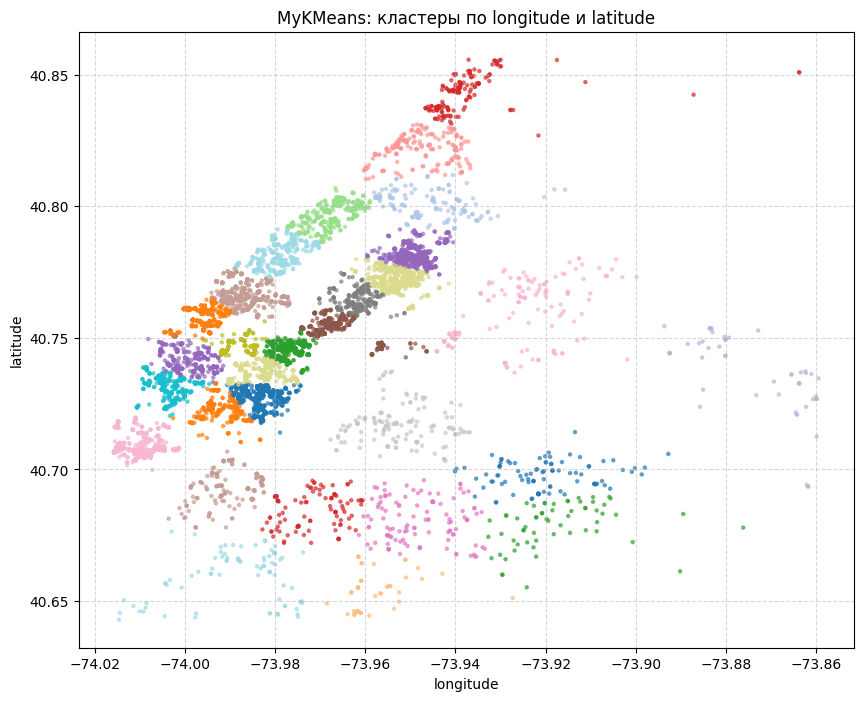

=== Мой K-means + Lasso ===
Лучший alpha: 0.01
R2 train: 0.664726
R2 test: 0.6639

                 name    importance
0             Balcony      1.327494
1        OutdoorSpace     42.854627
2               NoFee     43.269110
3         CatsAllowed     56.635997
4          Dishwasher     67.339019
5             Pre-War     75.257265
6         DogsAllowed     81.750783
7        SwimmingPool    111.202956
8       FitnessCenter    115.581200
9            RoofDeck    125.988757
10    NewConstruction    139.016690
11            Terrace    141.552454
12  LaundryinBuilding    153.861845
13     HardwoodFloors    179.390521
14  HighSpeedInternet    201.315350
15         DiningRoom    202.571019
16           Elevator    205.313618
17           latitude    249.017788
18  LaundryInBuilding    312.472460
19      LaundryinUnit    370.502720
20            Doorman    386.670951
21      cluster_label    447.662407
22     interest_level    783.840749
23          longitude   2466.468369
24           bedr

In [12]:
cluster_features_geo = ['longitude', 'latitude']

X_train_geo = X_train[cluster_features_geo].copy()
X_test_geo = X_test[cluster_features_geo].copy()

start_time = time.time()

my_kmeans = MyKMeans(n_clusters=30, random_state=21)
my_kmeans.fit(X_train_geo.values)

my_kmeans_time = time.time() - start_time

labels_train_my_kmeans = my_kmeans.predict(X_train_geo.values)
labels_test_my_kmeans = my_kmeans.predict(X_test_geo.values)

sil_my_kmeans = get_silhouette_score(X_train_geo, labels_train_my_kmeans)

print('Silhouette:', sil_my_kmeans)
print('Distortion:', my_kmeans.inertia_)
print('Время работы:', round(my_kmeans_time, 4), 'сек')

plot_clusters(X_test_geo, labels_test_my_kmeans, 'MyKMeans: кластеры по longitude и latitude')

X_train_my_kmeans = X_train.copy()
X_test_my_kmeans = X_test.copy()

X_train_my_kmeans['cluster_label'] = labels_train_my_kmeans
X_test_my_kmeans['cluster_label'] = labels_test_my_kmeans

_, importance_my_kmeans = fit_lasso_with_cluster_feature(
    X_train_my_kmeans,
    X_test_my_kmeans,
    y_train,
    y_test,
    'Мой K-means + Lasso'
)


## K-means из sklearn на признаках longitude и latitude


Silhouette: 0.4332778601274784
Distortion: 1.5518154141839082
Время работы: 0.8397 сек


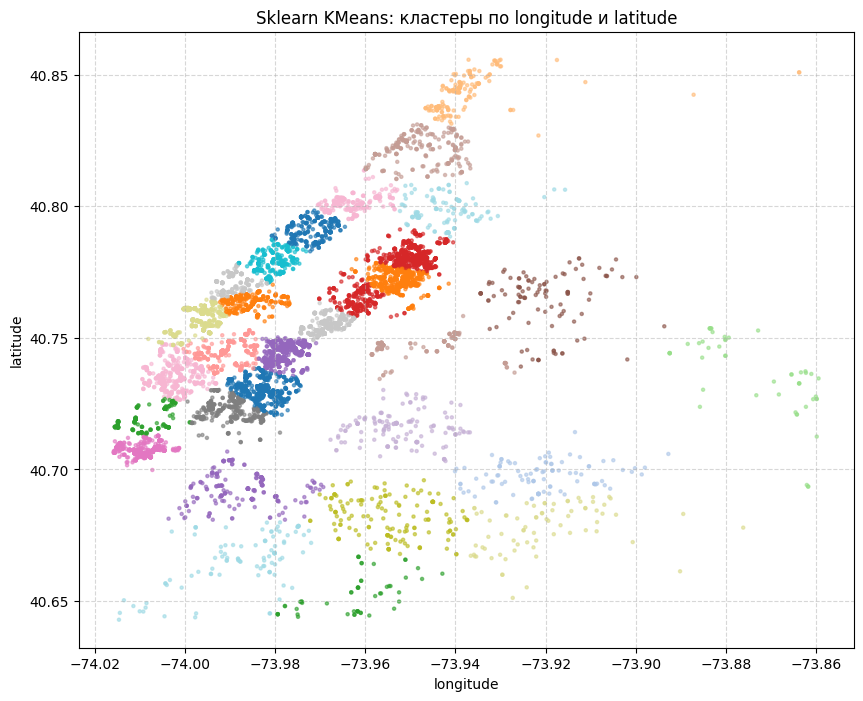

=== Sklearn KMeans + Lasso ===
Лучший alpha: 0.01
R2 train: 0.661798
R2 test: 0.659716

                 name    importance
0             Balcony     11.080721
1         CatsAllowed     37.838694
2               NoFee     52.828512
3        OutdoorSpace     56.613242
4         DogsAllowed     63.404693
5          Dishwasher     67.253039
6             Pre-War     73.009985
7     NewConstruction    108.863984
8        SwimmingPool    109.004613
9            RoofDeck    129.773363
10      FitnessCenter    140.923728
11            Terrace    155.147264
12  LaundryinBuilding    157.760671
13     HardwoodFloors    185.263790
14           latitude    195.362317
15  HighSpeedInternet    198.921102
16           Elevator    201.291775
17         DiningRoom    211.668942
18  LaundryInBuilding    303.626613
19      cluster_label    350.141184
20      LaundryinUnit    369.441824
21            Doorman    379.487001
22     interest_level    782.012773
23          longitude   2641.440800
24          

In [13]:
start_time = time.time()

sk_kmeans = KMeans(n_clusters=30, random_state=21, n_init=10)
labels_train_sk_kmeans = sk_kmeans.fit_predict(X_train_geo)
labels_test_sk_kmeans = sk_kmeans.predict(X_test_geo)

sk_kmeans_time = time.time() - start_time

sil_sk_kmeans = get_silhouette_score(X_train_geo, labels_train_sk_kmeans)

print('Silhouette:', sil_sk_kmeans)
print('Distortion:', sk_kmeans.inertia_)
print('Время работы:', round(sk_kmeans_time, 4), 'сек')

plot_clusters(X_test_geo, labels_test_sk_kmeans, 'Sklearn KMeans: кластеры по longitude и latitude')

X_train_sk_kmeans = X_train.copy()
X_test_sk_kmeans = X_test.copy()

X_train_sk_kmeans['cluster_label'] = labels_train_sk_kmeans
X_test_sk_kmeans['cluster_label'] = labels_test_sk_kmeans

_, importance_sk_kmeans = fit_lasso_with_cluster_feature(
    X_train_sk_kmeans,
    X_test_sk_kmeans,
    y_train,
    y_test,
    'Sklearn KMeans + Lasso'
)


## DBSCAN на признаках longitude и latitude


Silhouette: 0.17566667718140125
Количество кластеров без шума: 8
Время работы: 0.5971 сек


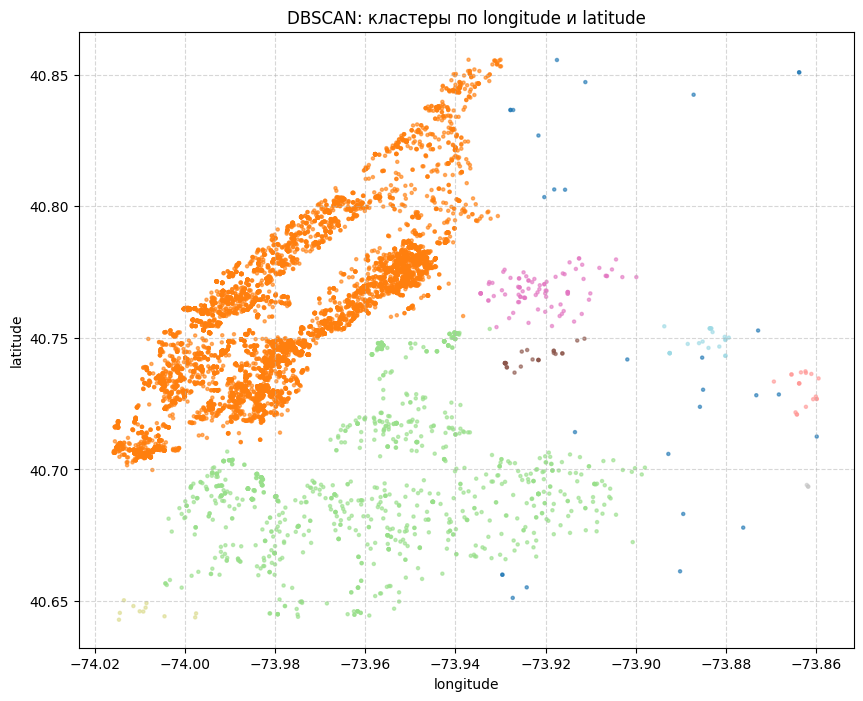

=== DBSCAN + Lasso ===
Лучший alpha: 0.01
R2 train: 0.658227
R2 test: 0.656355

                 name    importance
0             Balcony      8.066284
1         CatsAllowed     36.758343
2         DogsAllowed     60.154178
3               NoFee     60.660731
4        OutdoorSpace     61.742498
5             Pre-War     73.161986
6          Dishwasher     74.522987
7        SwimmingPool     98.125642
8       FitnessCenter    126.919026
9            RoofDeck    138.579371
10    NewConstruction    138.673333
11            Terrace    150.494275
12           latitude    154.744662
13  LaundryinBuilding    158.204833
14     HardwoodFloors    176.115337
15           Elevator    210.242661
16  HighSpeedInternet    211.268194
17         DiningRoom    216.610169
18      cluster_label    297.381542
19  LaundryInBuilding    300.121676
20      LaundryinUnit    368.138092
21            Doorman    388.333878
22     interest_level    784.957969
23          longitude   2397.467622
24           bedroom

In [14]:
start_time = time.time()

dbscan = DBSCAN(eps=0.005, min_samples=10)
labels_train_dbscan = dbscan.fit_predict(X_train_geo)

dbscan_time = time.time() - start_time

# Предсказание для test через 1-NN
knn_dbscan = KNeighborsClassifier(n_neighbors=1)
knn_dbscan.fit(X_train_geo, labels_train_dbscan)
labels_test_dbscan = knn_dbscan.predict(X_test_geo)

sil_dbscan = get_silhouette_score(X_train_geo, labels_train_dbscan)

print('Silhouette:', sil_dbscan)
print('Количество кластеров без шума:', len(set(labels_train_dbscan)) - (1 if -1 in labels_train_dbscan else 0))
print('Время работы:', round(dbscan_time, 4), 'сек')

plot_clusters(X_test_geo, labels_test_dbscan, 'DBSCAN: кластеры по longitude и latitude')

X_train_dbscan = X_train.copy()
X_test_dbscan = X_test.copy()

X_train_dbscan['cluster_label'] = labels_train_dbscan
X_test_dbscan['cluster_label'] = labels_test_dbscan

_, importance_dbscan = fit_lasso_with_cluster_feature(
    X_train_dbscan,
    X_test_dbscan,
    y_train,
    y_test,
    'DBSCAN + Lasso'
)


## AgglomerativeClustering на признаках longitude и latitude


Silhouette: 0.42869495939780444
Время работы: 0.3172 сек


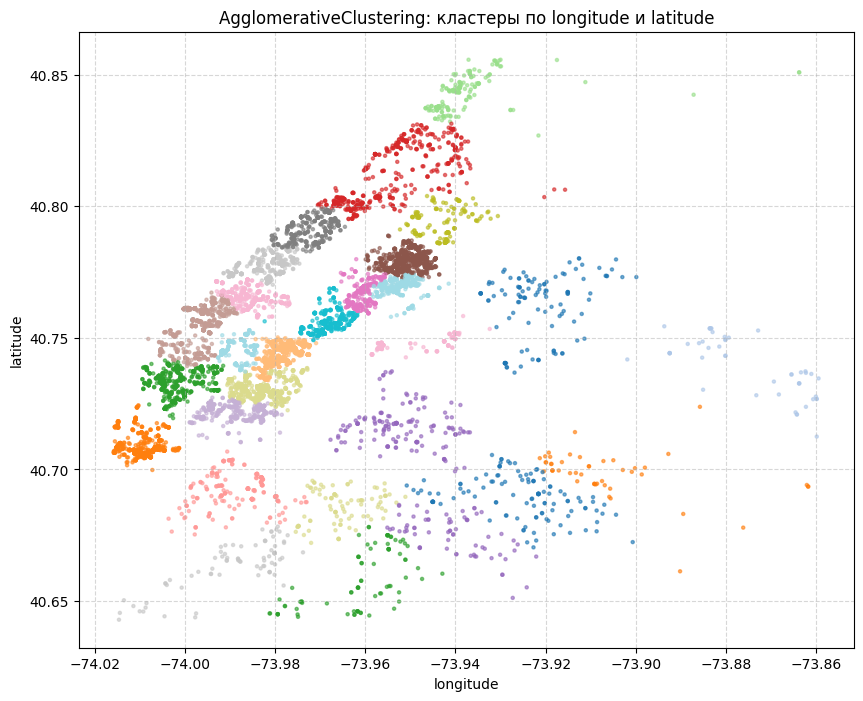

=== AgglomerativeClustering + Lasso ===
Лучший alpha: 0.01
R2 train: 0.661759
R2 test: 0.659219

                 name    importance
0             Balcony     11.156459
1               NoFee     53.814127
2        OutdoorSpace     65.302273
3          Dishwasher     65.342591
4         CatsAllowed     69.078545
5             Pre-War     74.203976
6            latitude     78.982383
7         DogsAllowed     94.289332
8        SwimmingPool     97.036864
9            RoofDeck    135.396229
10      FitnessCenter    135.697358
11    NewConstruction    145.479513
12            Terrace    153.312172
13  LaundryinBuilding    153.818920
14     HardwoodFloors    181.824874
15  HighSpeedInternet    208.331943
16         DiningRoom    209.421753
17           Elevator    216.617616
18  LaundryInBuilding    276.943875
19      cluster_label    346.145121
20      LaundryinUnit    369.988559
21            Doorman    381.520803
22     interest_level    781.963486
23          longitude   2482.528982
24 

In [15]:
start_time = time.time()

# Для ускорения используем подвыборку
sample_size = 5000
np.random.seed(21)
sample_idx = np.random.choice(len(X_train_geo), size=sample_size, replace=False)

X_train_geo_sample = X_train_geo.iloc[sample_idx].copy()

agglo = AgglomerativeClustering(n_clusters=30)
labels_sample_agglo = agglo.fit_predict(X_train_geo_sample)

agglo_time = time.time() - start_time

# Переносим метки на полную выборку через 1-NN
knn_agglo = KNeighborsClassifier(n_neighbors=1)
knn_agglo.fit(X_train_geo_sample, labels_sample_agglo)

labels_train_agglo = knn_agglo.predict(X_train_geo)
labels_test_agglo = knn_agglo.predict(X_test_geo)

sil_agglo = get_silhouette_score(X_train_geo, labels_train_agglo)

print('Silhouette:', sil_agglo)
print('Время работы:', round(agglo_time, 4), 'сек')

plot_clusters(X_test_geo, labels_test_agglo, 'AgglomerativeClustering: кластеры по longitude и latitude')

X_train_agglo = X_train.copy()
X_test_agglo = X_test.copy()

X_train_agglo['cluster_label'] = labels_train_agglo
X_test_agglo['cluster_label'] = labels_test_agglo

_, importance_agglo = fit_lasso_with_cluster_feature(
    X_train_agglo,
    X_test_agglo,
    y_train,
    y_test,
    'AgglomerativeClustering + Lasso'
)


## Gaussian Mixture на признаках longitude и latitude


Silhouette: 0.4165251398139669
Время работы: 0.5564 сек


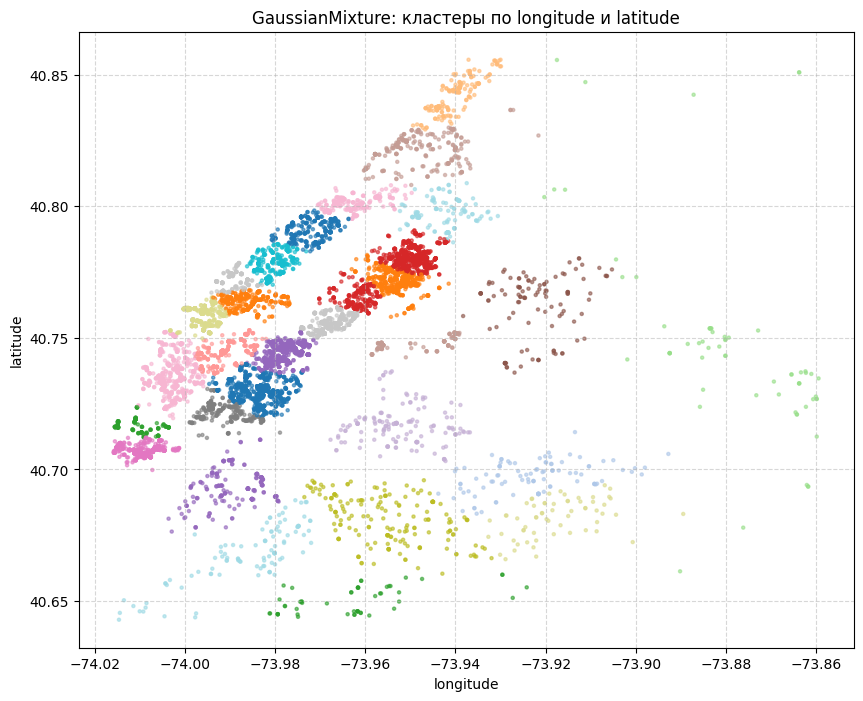

=== GaussianMixture + Lasso ===
Лучший alpha: 0.01
R2 train: 0.661544
R2 test: 0.659739

                 name    importance
0             Balcony     10.703667
1         CatsAllowed     38.725311
2               NoFee     50.553257
3        OutdoorSpace     59.681777
4         DogsAllowed     64.383530
5          Dishwasher     67.819670
6             Pre-War     73.487727
7        SwimmingPool    110.898282
8     NewConstruction    112.937612
9            RoofDeck    132.068807
10      FitnessCenter    143.246742
11            Terrace    154.968117
12  LaundryinBuilding    160.311815
13     HardwoodFloors    183.138783
14           latitude    194.949644
15  HighSpeedInternet    195.090662
16           Elevator    198.975761
17         DiningRoom    211.641466
18  LaundryInBuilding    304.902908
19      cluster_label    335.433172
20      LaundryinUnit    367.727045
21            Doorman    383.172698
22     interest_level    781.465333
23          longitude   2618.674881
24         

In [16]:
start_time = time.time()

gmm = GaussianMixture(n_components=30, random_state=21)
labels_train_gmm = gmm.fit_predict(X_train_geo)
labels_test_gmm = gmm.predict(X_test_geo)

gmm_time = time.time() - start_time

sil_gmm = get_silhouette_score(X_train_geo, labels_train_gmm)

print('Silhouette:', sil_gmm)
print('Время работы:', round(gmm_time, 4), 'сек')

plot_clusters(X_test_geo, labels_test_gmm, 'GaussianMixture: кластеры по longitude и latitude')

X_train_gmm = X_train.copy()
X_test_gmm = X_test.copy()

X_train_gmm['cluster_label'] = labels_train_gmm
X_test_gmm['cluster_label'] = labels_test_gmm

_, importance_gmm = fit_lasso_with_cluster_feature(
    X_train_gmm,
    X_test_gmm,
    y_train,
    y_test,
    'GaussianMixture + Lasso'
)


## Кластеризация на признаках bedrooms, bathrooms, interest_level


In [17]:
cluster_features_check = ['bedrooms', 'bathrooms', 'interest_level']

X_train_check = X_train[cluster_features_check].copy()
X_test_check = X_test[cluster_features_check].copy()


## K-means на признаках bedrooms, bathrooms, interest_level


In [18]:
kmeans_check = KMeans(n_clusters=30, random_state=21, n_init=10)
labels_train_kmeans_check = kmeans_check.fit_predict(X_train_check)
labels_test_kmeans_check = kmeans_check.predict(X_test_check)

X_train_kmeans_check = X_train.copy()
X_test_kmeans_check = X_test.copy()

X_train_kmeans_check['cluster_label'] = labels_train_kmeans_check
X_test_kmeans_check['cluster_label'] = labels_test_kmeans_check

_, importance_kmeans_check = fit_lasso_with_cluster_feature(
    X_train_kmeans_check,
    X_test_kmeans_check,
    y_train,
    y_test,
    'KMeans по bedrooms, bathrooms, interest_level + Lasso'
)


=== KMeans по bedrooms, bathrooms, interest_level + Lasso ===
Лучший alpha: 0.01
R2 train: 0.660113
R2 test: 0.658042

                 name    importance
0             Balcony      7.764814
1         CatsAllowed     36.849829
2        OutdoorSpace     61.397282
3               NoFee     62.279334
4         DogsAllowed     63.417446
5             Pre-War     73.946174
6          Dishwasher     79.425182
7        SwimmingPool    102.891243
8       FitnessCenter    127.743401
9            RoofDeck    139.731664
10    NewConstruction    142.017028
11            Terrace    147.117603
12  LaundryinBuilding    157.449098
13     HardwoodFloors    170.903761
14           Elevator    204.241530
15  HighSpeedInternet    208.768969
16         DiningRoom    211.426371
17           latitude    222.545755
18  LaundryInBuilding    302.359745
19      LaundryinUnit    364.059416
20            Doorman    395.116029
21      cluster_label    463.357040
22     interest_level    917.737685
23          longi

## AgglomerativeClustering на признаках bedrooms, bathrooms, interest_level


In [19]:
agglo_check = AgglomerativeClustering(n_clusters=30)
labels_sample_agglo_check = agglo_check.fit_predict(X_train_check.iloc[sample_idx])

knn_agglo_check = KNeighborsClassifier(n_neighbors=1)
knn_agglo_check.fit(X_train_check.iloc[sample_idx], labels_sample_agglo_check)

labels_train_agglo_check = knn_agglo_check.predict(X_train_check)
labels_test_agglo_check = knn_agglo_check.predict(X_test_check)

X_train_agglo_check = X_train.copy()
X_test_agglo_check = X_test.copy()

X_train_agglo_check['cluster_label'] = labels_train_agglo_check
X_test_agglo_check['cluster_label'] = labels_test_agglo_check

_, importance_agglo_check = fit_lasso_with_cluster_feature(
    X_train_agglo_check,
    X_test_agglo_check,
    y_train,
    y_test,
    'AgglomerativeClustering по bedrooms, bathrooms, interest_level + Lasso'
)


=== AgglomerativeClustering по bedrooms, bathrooms, interest_level + Lasso ===
Лучший alpha: 0.01
R2 train: 0.658091
R2 test: 0.656119

                 name    importance
0             Balcony      8.019540
1       cluster_label     22.707978
2         CatsAllowed     37.730389
3               NoFee     58.694347
4         DogsAllowed     59.014829
5        OutdoorSpace     62.023481
6             Pre-War     74.133420
7          Dishwasher     74.839683
8        SwimmingPool     97.126441
9       FitnessCenter    125.089571
10           RoofDeck    138.758291
11    NewConstruction    144.149227
12            Terrace    150.017117
13  LaundryinBuilding    156.832777
14     HardwoodFloors    174.890497
15           Elevator    208.523101
16  HighSpeedInternet    213.288059
17         DiningRoom    214.300813
18           latitude    223.755695
19  LaundryInBuilding    299.068900
20      LaundryinUnit    367.718340
21            Doorman    390.372458
22     interest_level    790.999206


## DBSCAN на признаках bedrooms, bathrooms, interest_level


In [20]:
dbscan_check = DBSCAN(eps=0.5, min_samples=10)
labels_train_dbscan_check = dbscan_check.fit_predict(X_train_check)

knn_dbscan_check = KNeighborsClassifier(n_neighbors=1)
knn_dbscan_check.fit(X_train_check, labels_train_dbscan_check)
labels_test_dbscan_check = knn_dbscan_check.predict(X_test_check)

X_train_dbscan_check = X_train.copy()
X_test_dbscan_check = X_test.copy()

X_train_dbscan_check['cluster_label'] = labels_train_dbscan_check
X_test_dbscan_check['cluster_label'] = labels_test_dbscan_check

_, importance_dbscan_check = fit_lasso_with_cluster_feature(
    X_train_dbscan_check,
    X_test_dbscan_check,
    y_train,
    y_test,
    'DBSCAN по bedrooms, bathrooms, interest_level + Lasso'
)


=== DBSCAN по bedrooms, bathrooms, interest_level + Lasso ===
Лучший alpha: 0.01
R2 train: 0.65905
R2 test: 0.65697

                 name    importance
0             Balcony      8.892422
1         CatsAllowed     38.264507
2               NoFee     60.558214
3         DogsAllowed     61.104600
4        OutdoorSpace     63.379699
5             Pre-War     73.756259
6          Dishwasher     78.074454
7        SwimmingPool     99.802984
8       FitnessCenter    127.324339
9            RoofDeck    138.049224
10    NewConstruction    143.640009
11            Terrace    153.413224
12  LaundryinBuilding    156.857257
13     HardwoodFloors    173.428189
14           Elevator    207.332873
15  HighSpeedInternet    211.889432
16         DiningRoom    212.383775
17           latitude    226.825151
18  LaundryInBuilding    302.767002
19      cluster_label    345.246278
20      LaundryinUnit    367.643570
21            Doorman    390.769451
22     interest_level    860.789198
23          longitu

## Gaussian Mixture на признаках bedrooms, bathrooms, interest_level


In [21]:
gmm_check = GaussianMixture(n_components=30, random_state=21)
labels_train_gmm_check = gmm_check.fit_predict(X_train_check)
labels_test_gmm_check = gmm_check.predict(X_test_check)

X_train_gmm_check = X_train.copy()
X_test_gmm_check = X_test.copy()

X_train_gmm_check['cluster_label'] = labels_train_gmm_check
X_test_gmm_check['cluster_label'] = labels_test_gmm_check

_, importance_gmm_check = fit_lasso_with_cluster_feature(
    X_train_gmm_check,
    X_test_gmm_check,
    y_train,
    y_test,
    'GaussianMixture по bedrooms, bathrooms, interest_level + Lasso'
)


=== GaussianMixture по bedrooms, bathrooms, interest_level + Lasso ===
Лучший alpha: 0.01
R2 train: 0.663066
R2 test: 0.661717

                 name    importance
0             Balcony      5.268362
1         CatsAllowed     36.732048
2        OutdoorSpace     60.221778
3               NoFee     61.575628
4         DogsAllowed     68.175268
5             Pre-War     69.388632
6          Dishwasher     79.570974
7        SwimmingPool     98.509775
8       FitnessCenter    125.525656
9            RoofDeck    136.617412
10    NewConstruction    139.925254
11            Terrace    142.474425
12  LaundryinBuilding    156.533776
13     HardwoodFloors    166.434350
14           Elevator    202.217237
15         DiningRoom    206.530505
16  HighSpeedInternet    208.965853
17           latitude    229.312152
18  LaundryInBuilding    293.153331
19      LaundryinUnit    362.202397
20            Doorman    391.223614
21      cluster_label    663.463598
22     interest_level    939.494789
23      

## Сравнение методов по скорости, сложности и качеству


In [22]:
comparison = pd.DataFrame({
    'Алгоритм': [
        'MyKMeans (geo)',
        'Sklearn KMeans (geo)',
        'DBSCAN (geo)',
        'Agglomerative (geo)',
        'GaussianMixture (geo)'
    ],
    'Silhouette': [
        sil_my_kmeans,
        sil_sk_kmeans,
        sil_dbscan,
        sil_agglo,
        sil_gmm
    ],
    'Время_сек': [
        my_kmeans_time,
        sk_kmeans_time,
        dbscan_time,
        agglo_time,
        gmm_time
    ],
    'Сложность_кратко': [
        'средняя',
        'средняя',
        'зависит от плотности',
        'высокая',
        'средняя'
    ]
})

comparison


,Алгоритм,Silhouette,Время_сек,Сложность_кратко
0,MyKMeans (geo),0.438990,41.261620,средняя
1,Sklearn KMeans (geo),0.433278,0.839689,средняя
2,DBSCAN (geo),0.175667,0.597056,зависит от плотности
3,Agglomerative (geo),0.428695,0.317197,высокая
4,GaussianMixture (geo),0.416525,0.556381,средняя


## Вывод

1. Был реализован собственный алгоритм K-means и проведено сравнение со sklearn.
2. Для признаков longitude и latitude были применены:
   - K-means,
   - DBSCAN,
   - AgglomerativeClustering,
   - GaussianMixture.
3. Для каждого алгоритма метки кластеров были добавлены как новый признак в модель Lasso с MinMaxScaler.
4. Были выведены значения silhouette score, distortion для K-means и важности признаков.
5. Те же алгоритмы были применены к признакам bedrooms, bathrooms и interest_level.
6. Проведено сравнение методов по скорости, сложности и качеству.
